# 7. Diagrams versus cumulant closures of order 2, 3, 4 — Fig. 9 and SM Table SI (Sec. VI.B)

Cumulant closures keep all moments up to order $N_c$ and set every higher joint cumulant to zero. At $N_c=2$ this is Hartree–Fock–Bogoliubov theory, a Gaussian theory that evaluates $g^{(3)}$ by Wick's theorem; at $N_c=3,4$ part of the non-Gaussian content is retained. For the three-site ring the closures contain 27, 83, and 209 moment variables.

**Part A** runs the single-cavity comparison with the second-order closure (the closure fails silently near the bistability while the diagrammatic terms turn over). **Part B** regenerates Fig. 9 and Table SI of the SM from `benchmarks/cumulant_closures/` (closures of order 2–4 and diagrams through order 10 on the $K=3$ ring against the converged displaced-frame exact steady state) and prints the numbers of Sec. VI.B.

In [1]:
from common import *
FAST = True      # True: reduced orders and cutoffs, minutes.  False: the orders and cutoffs of the paper (see the runtime note)
print("repository:", os.path.basename(CODE), "| FAST =", FAST, "| paper sources:", "found" if PAPER else "not present (Tables V and SI from notebooks/paper_reference/)")

repository: gh_staging | FAST = True | paper sources: not present (Tables V and SI from notebooks/paper_reference/)


## Part A — single Kerr cavity against the second-order closure

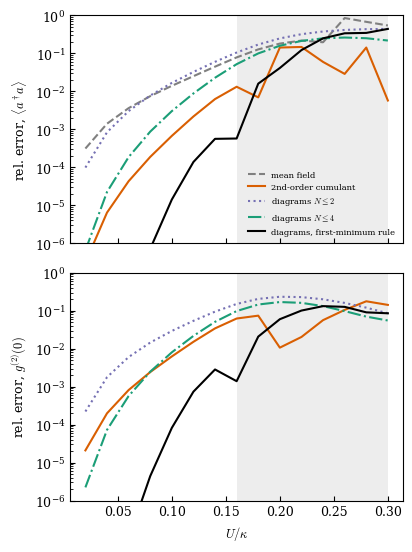

U=0.2: closure error on n = 0.143 (converged, no internal warning)


In [2]:
from cumulant import kerr_cumulant_ss
kappa, Dc, eta = 1.0, -1.0, 1.0
z = kappa/2 + 1j*Dc; alpha = eta/z
a, ad, b, bd = mode_ops(alpha)
mod = Model(1, z, lambda X: 0*X, np.eye(1), scale(0.5, mul(mul(ad,ad), mul(a,a))), 4)
Nmax = 12 if FAST else 16
cn = moment_series(mod, 1, 1, alpha, Nmax).real; cn2 = moment_series(mod, 2, 2, alpha, Nmax).real
def kerr_exact_rho(U, Nc=30):
    A_ = destroy(Nc); Ad_ = A_.conj().T
    H = Dc*Ad_@A_ + 1j*(eta*Ad_ - np.conj(eta)*A_) + U/2*Ad_@Ad_@A_@A_
    rho = steady(H, [np.sqrt(kappa)*A_]); n = np.trace(Ad_@A_@rho).real
    return n, np.trace(Ad_@Ad_@A_@A_@rho).real/n**2
def kerr_meanfield(U):
    r = np.roots([U**2, 2*Dc*U, Dc**2+kappa**2/4, -abs(eta)**2]) if U>0 else [abs(alpha)**2]
    r = np.array(r); return float(np.min(r[np.abs(np.imag(r))<1e-9].real))
def first_min(t):
    t = np.abs(t)
    for k in range(2, len(t)-1):
        if t[k+1] > t[k]: return k
    return len(t)-1
Uc = np.linspace(0.02, 0.3, 15 if FAST else 29)
E = {k: [] for k in ['mf','hfb','N2','N4','st']}; G = {k: [] for k in ['hfb','N2','N4','st']}
x0 = None
for U in Uc:
    n_ex, g_ex = kerr_exact_rho(U)
    pw_=U**np.arange(Nmax+1); pn_=np.cumsum(cn*pw_); pg_=np.cumsum(cn2*pw_)/pn_**2
    kst=first_min(cn*pw_)
    c=kerr_cumulant_ss(kappa,Dc,eta,U,x0=x0); x0=c['x']
    E['mf'].append(abs(kerr_meanfield(U)/n_ex-1)); E['hfb'].append(abs(c['n']/n_ex-1))
    E['N2'].append(abs(pn_[2]/n_ex-1)); E['N4'].append(abs(pn_[4]/n_ex-1)); E['st'].append(abs(pn_[kst]/n_ex-1))
    G['hfb'].append(abs(c['g2']/g_ex-1)); G['N2'].append(abs(pg_[2]/g_ex-1)); G['N4'].append(abs(pg_[4]/g_ex-1)); G['st'].append(abs(pg_[kst]/g_ex-1))
sty={'mf':('mean field','0.5','--'),'hfb':('2nd-order cumulant',COL[0],'-'),'N2':('diagrams $N\\leq2$',COL[2],':'),
     'N4':('diagrams $N\\leq4$',COL[1],'-.'),'st':('diagrams, first-minimum rule','k','-')}
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(4.2,5.6),sharex=True)
for k in E: ax1.semilogy(Uc,np.maximum(E[k],1e-7),color=sty[k][1],ls=sty[k][2],label=sty[k][0])
for k in G: ax2.semilogy(Uc,np.maximum(G[k],1e-7),color=sty[k][1],ls=sty[k][2],label=sty[k][0])
for ax in (ax1,ax2): ax.axvspan(0.16,0.3,color='0.93',lw=0); ax.set_ylim(1e-6,1)
ax1.set_ylabel(r'rel. error, $\langle a^\dagger a\rangle$'); ax2.set_ylabel('rel. error, $g^{(2)}(0)$')
ax2.set_xlabel('$U/\\kappa$'); ax1.legend(fontsize=6)
fig.tight_layout(); plt.show()
k=np.argmin(abs(Uc-0.2)); print(f"U=0.2: closure error on n = {E['hfb'][k]:.3f} (converged, no internal warning)")

## Part B — Fig. 9 and SM Table SI

Recomputation: `run_cumulants.py` (closures 2–4 and diagrams through order 4, minutes), `exact_disp.py` (converged exact reference, ~1 h), `diag_run.py` (diagrams through order 10). Assembly: `assemble.py` → `cumulant_closure_results.json`; `make_fig_g3.py` draws the figure.

$ (cd code/benchmarks/cumulant_closures; python3 assemble.py)   [15.9 s, exit 0]
opt 0.250 g3 err 3.11e-02 delta_rel 1.35e-03 true/delta 23.0 bestclosure/opt 0.63 | g2 err 4.25e-03 bestclosure/opt 0.04
opt 0.275 g3 err 6.10e-02 delta_rel 2.40e-03 true/delta 25.4 bestclosure/opt 0.32 | g2 err 9.57e-03 bestclosure/opt 0.09
opt 0.300 g3 err 1.05e-01 delta_rel 3.91e-03 true/delta 26.9 bestclosure/opt 0.18 | g2 err 1.70e-02 bestclosure/opt 0.14


$ (cd code/benchmarks/cumulant_closures; python3 make_fig_g3.py)   [1.2 s, exit 0]
wrote fig_g3.pdf


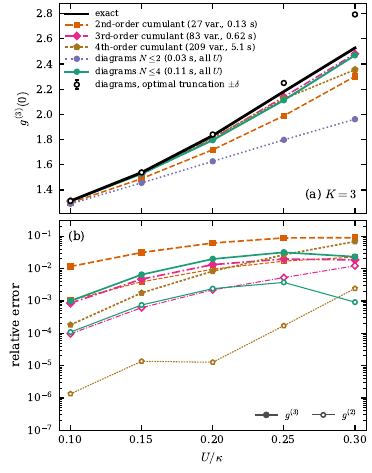

In [3]:
run("python3 assemble.py", "benchmarks/cumulant_closures", timeout=600)
run("python3 make_fig_g3.py", "benchmarks/cumulant_closures")
paper_figure("benchmarks/cumulant_closures/fig_g3.pdf")

## Part C — the recursion as a sparse matrix built once (`engines/sparse_ring.py`)

The recursion $X_N=\mathcal V\mathcal G_0X_{N-1}$ is linear, so the map "vertex after propagator" is a matrix on the labels. `SparseRing` enumerates the reachable zero-momentum labels layer by layer (degree $\le 2(N_{\max}-N)$ after vertex $N$), computes each column once, and runs the series as sparse matrix–vector products. The vertex is proportional to $U$, so the matrix is built at $U=1$ and the $N$th-order term is $c_NU^N$: one run gives every coupling. This is what the cost figures in Table SI and Sec. VI.B refer to; `benchmarks/truncation/sparse_ring_timing.py` records the timings and `engines/check_sparse_ring.py` the validation.

In [4]:
import multimode as MM
from sparse_ring import SparseRing
R = SparseRing(K=3, kappa=1.0, Delta=-1.0, J=0.4, eta=1.0); b, bd = R.site_ops(0)
obs = {"n": MM.mul(bd, b), "n2": MM.mul(MM.mul(bd, bd), MM.mul(b, b)), "n3": MM.mul(MM.mul(MM.mul(bd, bd), bd), MM.mul(MM.mul(b, b), b))}
t0 = time.time(); coef = {k: R.coefficients(O, 10) for k, O in obs.items()}; print(f"orders 0-10 of n, n2, n3, all couplings: {time.time()-t0:.1f} s")
T = J("benchmarks", "truncation", "truncation_results.json")["ring_K3"]["results"]
worst = 0.0
for U in T:
    u = float(U)
    if u == 0: continue
    n = R.partial_sums(coef["n"], u); g2 = R.partial_sums(coef["n2"], u)/n**2; g3 = R.partial_sums(coef["n3"], u)/n**3
    for q, mine in (("n", n), ("g2", g2), ("g3", g3)):
        ref = np.array(T[U][q]["partial_sums"]); worst = max(worst, float(np.max(np.abs(mine.real-ref)/np.abs(ref))))
print(f"max relative difference from the stored symbolic-recursion partial sums (13 couplings x 3 quantities x 11 orders): {worst:.1e}")
print("labels per layer, n3, Nmax=10:", R.coefficients(obs["n3"], 10, return_counts=True)[1])
ST = J("benchmarks", "truncation", "sparse_ring_timing.json")
print("scaling of the construction with K (g2, one core):", {K: {N: f"{v['t']:.2f} s" for N, v in ST["scaling"][K].items()} for K in ST["scaling"] if K.isdigit()})

orders 0-10 of n, n2, n3, all couplings: 4.8 s
max relative difference from the stored symbolic-recursion partial sums (13 couplings x 3 quantities x 11 orders): 9.1e-16


labels per layer, n3, Nmax=10: [136, 408, 1045, 2355, 3702, 2484, 1005, 312, 72, 10, 1]
scaling of the construction with K (g2, one core): {'3': {'2': '0.02 s', '4': '0.10 s'}, '4': {'2': '0.05 s', '4': '0.40 s'}, '5': {'2': '0.11 s', '4': '1.10 s'}, '6': {'2': '0.26 s', '4': '2.88 s'}, '8': {'2': '0.85 s', '4': '16.34 s'}, '10': {'2': '2.91 s', '4': '69.42 s'}, '12': {'2': '7.54 s', '4': '235.94 s'}}


In [5]:
C = J("benchmarks", "cumulant_closures", "cumulant_closure_results.json")
O = C["optimal_truncation_diagrams"]["results"]; tab = {row["U"]: row for row in C["table_fig11"]}
print("SM Table SI: relative errors (columns: closure 2 | 3 | 4 | diagrams N<=2 | N<=4 | optimally truncated, N*)")
for row in C["table_fig11"]:
    U = row["U"]; o = O[f"{U:.3f}"]
    print(f"  U={U:<5} g3: " + " | ".join(f"{row[k]['err_g3']:.1e}" for k in ("closure2","closure3","closure4","diagrams2","diagrams4")) + f" | {o['g3']['err_vs_converged_exact']:.1e} (N*={o['g3']['N_star']})")
    print(f"          g2: " + " | ".join(f"{row[k]['err_g2']:.1e}" for k in ("closure2","closure3","closure4","diagrams2","diagrams4")) + f" | {o['g2']['err_vs_converged_exact']:.1e} (N*={o['g2']['N_star']})")
best = lambda U: min(tab[U]["closure3"]["err_g3"], tab[U]["closure4"]["err_g3"])
print("\nSec. VI.B")
quoted("closure variables at order 2, 3, 4", "27, 83, 209", ", ".join(str(C["variables_per_order"][k]) for k in ("2","3","4")))
t = lambda k: np.median([tab[U][k]["t"] for U in tab])
quoted("cost per evaluation (s): closures 2, 3, 4", "0.13, 0.6, 5", f"{t('closure2'):.2f}, {t('closure3'):.1f}, {t('closure4'):.1f}")
DC = C["diagram_cost"]
quoted("cost per coupling (s): diagrams N<=2, N<=4, pruned recursion", "0.25, 1.0", f"{DC['pruned_per_U']['2']:.2f}, {DC['pruned_per_U']['4']:.2f}")
quoted("cost for all couplings (s): sparse-matrix form, orders 0-2, 0-4, 0-10", "0.04, 0.12, 4.3", f"{DC['sparse_all_U']['2']:.2f}, {DC['sparse_all_U']['4']:.2f}, {DC['sparse_all_U']['10']:.1f}")
quoted("   (unpruned recursion of diag_run.py, per coupling: N<=2, N<=4)", "", f"{DC['unpruned_per_U']['2']:.1f}, {DC['unpruned_per_U']['4']:.0f}")
quoted("U=0.1: exact g3", 1.3126, tab[0.1]["exact_g3"], "{:.4f}")
quoted("U=0.1: HFB g3 error / diagrams-4 g3 error (factor 12)", 12, tab[0.1]["closure2"]["err_g3"]/tab[0.1]["diagrams4"]["err_g3"], "{:.1f}")
quoted("U=0.1: HFB / diagrams-4 g3 errors (%)", "1.2 / 0.10", f"{100*tab[0.1]['closure2']['err_g3']:.1f} / {100*tab[0.1]['diagrams4']['err_g3']:.2f}")
quoted("U=0.1: diagrams-4 worse than best closure by", 5.5, tab[0.1]["diagrams4"]["err_g3"]/best(0.1), "{:.1f}")
quoted("U=0.3: diagrams-4 worse than best closure by", 1.25, tab[0.3]["diagrams4"]["err_g3"]/best(0.3), "{:.2f}")
quoted("N* of the optimal truncation, U=0.1 ... 0.3", "8-10", f"{min(O[U]['g3']['N_star'] for U in O if float(U)>0)}-{max(O[U]['g3']['N_star'] for U in O if float(U)>0)}")
for U, p in (("0.100", 1.8e-6), ("0.150", 3.2e-4), ("0.200", 4.9e-3)): quoted(f"U={U}: optimally truncated g3 error", p, O[U]["g3"]["err_vs_converged_exact"], "{:.1e}")
for U, p in (("0.100", 100), ("0.150", 5.5), ("0.200", 1.7), ("0.225", 1.0)): quoted(f"U={U}: better than best closure by", p, O[U]["g3"]["best_closure_err_over_optimal_diagram_err"], "{:.2f}")
for U, p in (("0.250", 1.6), ("0.300", 5.5)): quoted(f"U={U}: worse than best closure by", p, 1/O[U]["g3"]["best_closure_err_over_optimal_diagram_err"], "{:.2f}")
allg = [tab[U][k][g] for U in tab for k in ("closure2","closure3","closure4","diagrams2","diagrams4") for g in ("g2","g3")]
quoted("smallest plotted correlator (all above one)", ">1", min(allg), "{:.4f}")

SM Table SI: relative errors (columns: closure 2 | 3 | 4 | diagrams N<=2 | N<=4 | optimally truncated, N*)
  U=0.1   g3: 1.2e-02 | 8.5e-04 | 1.8e-04 | 1.7e-02 | 1.0e-03 | 1.8e-06 (N*=10)
          g2: 1.0e-03 | 9.6e-05 | 1.3e-06 | 2.9e-03 | 1.1e-04 | 1.5e-07 (N*=10)
  U=0.15  g3: 3.1e-02 | 4.7e-03 | 1.8e-03 | 5.3e-02 | 6.5e-03 | 3.2e-04 (N*=8)
          g2: 3.9e-03 | 6.2e-04 | 1.4e-05 | 9.8e-03 | 7.5e-04 | 4.0e-05 (N*=8)
  U=0.2   g3: 6.1e-02 | 1.3e-02 | 8.3e-03 | 1.1e-01 | 2.0e-02 | 4.9e-03 (N*=8)
          g2: 9.6e-03 | 2.2e-03 | 1.3e-05 | 2.2e-02 | 2.4e-03 | 6.3e-04 (N*=8)
  U=0.25  g3: 8.8e-02 | 2.0e-02 | 2.7e-02 | 1.8e-01 | 3.2e-02 | 3.1e-02 (N*=8)
          g2: 1.7e-02 | 5.3e-03 | 1.7e-04 | 3.9e-02 | 3.7e-03 | 4.2e-03 (N*=8)
  U=0.3   g3: 8.9e-02 | 1.8e-02 | 6.8e-02 | 2.2e-01 | 2.3e-02 | 1.1e-01 (N*=8)
          g2: 2.3e-02 | 1.2e-02 | 2.4e-03 | 5.4e-02 | 9.1e-04 | 1.7e-02 (N*=7)

Sec. VI.B
  closure variables at order 2, 3, 4                             paper  27, 83, 209   code